## Routing

In [1]:
# Run this only if packages are not installed
# !pip install langgraph langchain-openai typing_extensions

In [2]:
import os
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

import getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

C:\Users\ruthi\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class State(TypedDict):
    question: str
    route: str
    answer: str

## Router node

In [4]:
def router_node(state: State):
    prompt = f"""
You are a question router.

Classify the student question into only one category:

1. math
2. python
3. general

Question:
{state["question"]}

Return only one word:
math, python, or general
"""

    response = llm.invoke(prompt)
    route = response.content.strip().lower()

    if route not in ["math", "python", "general"]:
        route = "general"

    return {"route": route}

Routing function

In [5]:
def decide_route(state: State):
    return state["route"]

Math teacher node

In [6]:
def math_teacher(state: State):
    prompt = f"""
You are a math teacher.

Explain the answer step by step in simple language.

Question:
{state["question"]}
"""

    response = llm.invoke(prompt)
    return {"answer": response.content}

Python teacher node

In [7]:
def python_teacher(state: State):
    prompt = f"""
You are a Python programming teacher.

Explain the answer clearly for a beginner.
Use code example if helpful.

Question:
{state["question"]}
"""

    response = llm.invoke(prompt)
    return {"answer": response.content}

General teacher node

In [8]:
def general_teacher(state: State):
    prompt = f"""
You are a helpful teacher.

Answer the question in simple and clear language.

Question:
{state["question"]}
"""

    response = llm.invoke(prompt)
    return {"answer": response.content}


Building routing workflow.

In [9]:
workflow = StateGraph(State)

workflow.add_node("router_node", router_node)
workflow.add_node("math_teacher", math_teacher)
workflow.add_node("python_teacher", python_teacher)
workflow.add_node("general_teacher", general_teacher)

workflow.add_edge(START, "router_node")

workflow.add_conditional_edges(
    "router_node",
    decide_route,
    {
        "math": "math_teacher",
        "python": "python_teacher",
        "general": "general_teacher",
    },
)

workflow.add_edge("math_teacher", END)
workflow.add_edge("python_teacher", END)
workflow.add_edge("general_teacher", END)

chain = workflow.compile()

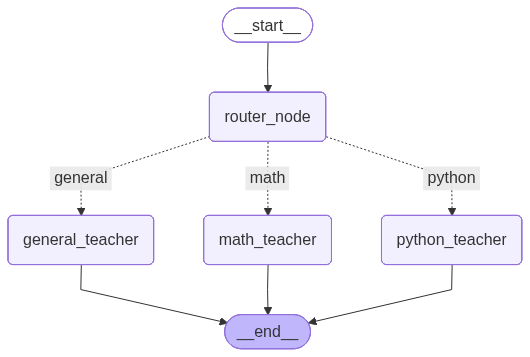

In [10]:
display(Image(chain.get_graph().draw_mermaid_png()))

In [11]:
result = chain.invoke({
    "question": "What is the difference between mean and median?"
})

print("Selected Route:")
print(result["route"])

print("\nAnswer:")
print(result["answer"])

Selected Route:
math

Answer:
Sure! Let's break down the concepts of mean and median step by step.

### Mean

1. **Definition**: The mean is what most people commonly refer to as the "average."
  
2. **How to Calculate**:
   - **Step 1**: Add up all the numbers in your data set.
   - **Step 2**: Count how many numbers are in the data set.
   - **Step 3**: Divide the total from Step 1 by the count from Step 2.

3. **Example**: 
   - Let's say we have the numbers: 2, 4, 6, 8, 10.
   - **Step 1**: Add them up: 2 + 4 + 6 + 8 + 10 = 30.
   - **Step 2**: Count the numbers: There are 5 numbers.
   - **Step 3**: Divide the total by the count: 30 ÷ 5 = 6.
   - So, the mean is 6.

### Median

1. **Definition**: The median is the middle number in a data set when the numbers are arranged in order.

2. **How to Calculate**:
   - **Step 1**: Arrange the numbers in ascending (from smallest to largest) order.
   - **Step 2**: Find the middle number.
     - If there is an odd number of values, the medi